# Site-Specific NRX Training Tutorial

This notebook provides a guide to the pretraining and site-specific finetuning workflow in the `neural_rx` repository, as described in [[1]](#ref-1) and [[2]](#ref-2). It explains how to pretrain an NRX on synthetic channels, extract a finetuning TFRecord from the NVIDIA Aerial Data Lake, finetune the pretrained model with real-world data, export the trained model to ONNX/TensorRT, and evaluate it on a deterministic set of real-world measurements.

The command cells below print or describe operations that can be computationally expensive. They are intentionally not executed automatically. Run these commands in a shell rather than from the notebook. Avoid other GPU-intensive workloads while the scripts are running, as GPU contention can affect the results.

## Contents

- [1. Prerequisites and repository paths](#prerequisites)
- [2. The configuration parameters](#configuration)
  - [2.1 Modified pretraining configuration](#pretraining-configuration)
- [3. Pretrain the NRX on synthetic channels](#pretraining)
- [4. Extract a finetuning TFRecord from NVIDIA Aerial Data Lake](#tfrecord-extraction)
- [5. Finetune with the Data Lake Channel](#finetuning)
- [6. Compile the finetuned NRX](#compilation)
- [7. Evaluate on real-world data](#evaluation)
- [8. Examine the results](#results)
- [References](#references)


<a id="prerequisites"></a>

## 1. Prerequisites and Repository Paths

The required packages are listed in [`requirements.txt`](../requirements.txt). Check [`README.md`](../README.md) for the complete environment notes.

Real-data steps require a running ClickHouse-backed Aerial Data Lake, databases containing the required `fapi` and `fh` tables, and NVIDIA pyAerial. The databases are not included in the repository; detailed information and download instructions are provided in [`datasets.md`](../../datasets.md).

In [1]:
from pathlib import Path
import os

candidates = (Path.cwd(), *Path.cwd().parents)
WORKSPACE_ROOT = next((path.resolve() for path in candidates if path.name == 'rx_training' and (path / 'neural_rx' / 'config').is_dir() and (path / 'neural_rx' / 'scripts').is_dir()), None)
if WORKSPACE_ROOT is None:
    raise RuntimeError('Could not locate the rx_training workspace root.')

os.chdir(WORKSPACE_ROOT)
REPO = Path('neural_rx')
DISPLAY_ROOT = Path('/rx_training')

print(f'Workspace root: {DISPLAY_ROOT}')
print(f'Repository: {DISPLAY_ROOT / REPO}')

Workspace root: /rx_training
Repository: /rx_training/neural_rx


<a id="configuration"></a>

## 2. The Configuration Parameters

Every experiment is driven by a file in `config/`. Its `global.label` becomes the prefix for weights and exported artifacts. The pretraining configuration uses randomized 3GPP UMi channels implemented in Sionna, while real-data finetuning uses `channel_type = 'Datalake'` and sets `datalake_tf_fn` to the appropriate TFRecord.

The configuration must match the measured resource-grid dimensions, number of receive antennas, and number of active uplink layers. Because the TFRecord stores coded bits on the OFDM grid and marks pilot positions, BCE supervision is agnostic to MCS, scrambling, and DMRS placement within those supported tensor dimensions.

The tables in [`datasets.md`](../../datasets.md) list the configurations used in the experiments. Deep variants evaluate all eight CGNN iterations; Shallow variants evaluate two and use the `_rt` suffix. Multi-loss training provides a readout after every iteration, so both depths reuse the same trained weights. An uplink layer (ULL) denotes one active spatial transmission layer; the 1 ULL and 2 ULL datasets contain one and two active uplink layers, respectively.

All finetuning configurations select `channel_type = 'Datalake'` and point `datalake_tf_fn` to the corresponding scenario TFRecord stored in `/rx_training/finetuning_datasets/`.


The following code snippet selects the Deep NRX pretraining configuration with the 3GPP UMi channel model and the finetuning configuration for the Nov. 2025 Small Laboratory single-layer dataset.

In [2]:
from neural_rx.notebooks.notebook_helpers import NotebookHelpers

notebook = NotebookHelpers(WORKSPACE_ROOT, DISPLAY_ROOT)

pretraining_config = 'nrx_large_3dmrs_13sym1.cfg'
finetuning_config = 'nrx_datalake_novj61.cfg'

pretraining_config_path = REPO / 'config' / pretraining_config
finetuning_config_path = REPO / 'config' / finetuning_config

pretraining_label = notebook.config_value(pretraining_config_path, 'label')
finetuning_label = notebook.config_value(finetuning_config_path, 'label')
finetuning_dataset = notebook.config_value(finetuning_config_path, 'datalake_tf_fn')

notebook.show_config(pretraining_config_path)
notebook.show_config(finetuning_config_path)

--- /rx_training/neural_rx/config/nrx_large_3dmrs_13sym1.cfg

label = 'nrx_large_3dmrs_13sym1' # all relevant files such as weights will use this label
max_num_tx = 2 # max number of active DMRS ports
channel_type = 'UMi'
#channel_type = 'DoubleTDLlow'

--- /rx_training/neural_rx/config/nrx_datalake_novj61.cfg

label = 'nrx_datalake_novj61' # all relevant files such as weights will use this label
max_num_tx = 1 # max number of active DMRS ports
channel_type = 'Datalake' # requires pre-generated dataset
datalake_tf_fn = 'nrx_measurement_2025_11_03.tfrecord' # tfrecord created from datalake (only relevant if channel type is Datalake)



<a id="pretraining-configuration"></a>

### 2.1 Modified Pretraining Configuration

The [`nrx_large_3dmrs_13sym1.cfg`](../config/nrx_large_3dmrs_13sym1.cfg) pretraining configuration matches the resource grid used by the 5G NR testbed at ETH Zurich, which builds upon the NVIDIA Aerial Testbed (ATB) software platform [[1]](#ref-1). Compared with the original configuration, it uses:

- Three DMRS symbols instead of two.
- Zero-based DMRS symbol positions `[0, 5, 10]`.
- Thirteen OFDM symbols instead of fourteen.

The cell below visualizes this DMRS pilot pattern over four PRBs (48 subcarriers).


2026-09-04 08:59:07.194086: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9373] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-04 08:59:07.194117: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-04 08:59:07.194706: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1534] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-04 08:59:07.772310: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Evaluating the first 2 port sets.


2026-09-04 08:59:09.020979: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1926] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 94697 MB memory:  -> device: 0, name: NVIDIA GH200 480GB, pci bus id: 0009:01:00.0, compute capability: 9.0


Config: nrx_large_3dmrs_13sym1.cfg
Number of configured transmitters/MCS entries: 1
Grid shape (OFDM symbols, subcarriers): (13, 48)
DMRS port sets: [[0], [2]]
Number of CDM groups without data: 2


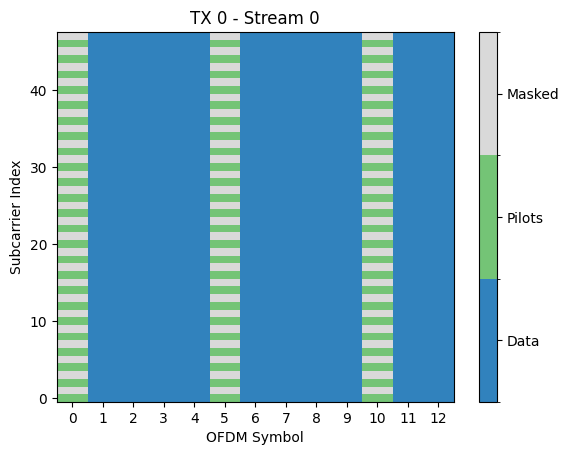

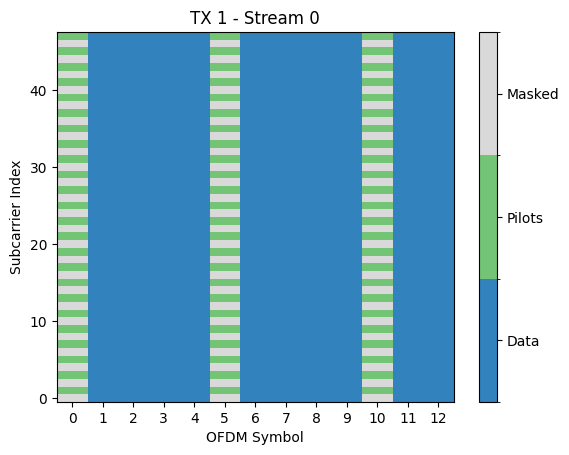

In [3]:
import os
import sys
import matplotlib.pyplot as plt

sys.path.insert(0, str(REPO))
from utils.parameters import Parameters

config_name = pretraining_config
original_cwd = Path.cwd()

try:
    os.chdir(REPO / 'scripts')
    sys_parameters = Parameters(config_name, system='nrx', training=True)
finally:
    os.chdir(original_cwd)

transmitter = sys_parameters.transmitters[0]
pilot_pattern = transmitter.pilot_pattern
resource_grid_types = transmitter.resource_grid.build_type_grid().numpy()

print(f'Config: {config_name}')
print(f'Number of configured transmitters/MCS entries: {len(sys_parameters.transmitters)}')
print(f'Grid shape (OFDM symbols, subcarriers): {resource_grid_types.shape[-2:]}')
print(f'DMRS port sets: {sys_parameters.dmrs_port_sets}')
print(f'Number of CDM groups without data: {sys_parameters.num_cdm_groups_without_data}')

pilot_pattern.show()
plt.show()

<a id="pretraining"></a>

## 3. Pretrain the NRX on Synthetic Channels

Pretraining follows the workflow of the original [`NVlabs/neural_rx`](https://github.com/NVlabs/neural_rx) repository [[3]](#ref-3). It initializes the receiver parameters before site-specific adaptation. Start with a pretraining configuration such as `nrx_large_3dmrs_13sym1.cfg`, inspect its training schedule and model dimensions, and run [`train_neural_rx.py`](../scripts/train_neural_rx.py).

Training saves the weights to [`/rx_training/neural_rx/weights/`](../weights/) and the logs to [`/rx_training/neural_rx/logs/`](../logs/). Depending on the hardware configuration, pretraining might take a long time. The weights used for this experiment are provided, so pretraining can be skipped when reproducing the workflow.

In [6]:
pretrained_weights = REPO / 'weights' / f'{pretraining_label}_weights'
pretraining_command = f'''
cd {notebook.display_path(REPO / 'scripts')}
python train_neural_rx.py -config_name {pretraining_config}
'''.strip()

notebook.show_terminal(
    pretraining_command,
    [('Weights to be saved at', notebook.display_path(pretrained_weights))],
)
# os.system(pretraining_command)

```bash
$ cd /rx_training/neural_rx/scripts
$ python train_neural_rx.py -config_name nrx_large_3dmrs_13sym1.cfg
```

```text
Weights to be saved at: /rx_training/neural_rx/weights/nrx_large_3dmrs_13sym1_weights
```

<a id="tfrecord-extraction"></a>

## 4. Extract a Finetuning TFRecord from NVIDIA Aerial Data Lake

The NRX is a fully-tunable MIMO detector trained through supervised learning with ground-truth coded-bit labels. [`create_tfrecord_from_data_multicell.py`](../scripts/create_tfrecord_from_data_multicell.py) creates the required TFRecord files containing received IQ samples, coded-bit labels, and LS channel estimates provided as an additional receiver input. It connects to ClickHouse at `localhost`, selects a measurement database, reads the PUSCH FAPI metadata and fronthaul (FH) data, and writes a TensorFlow-compatible TFRecord.

The finetuning dataset is sampled such that approximately 10% of its transport blocks fail with the MMSE Reference Rx, ensuring that the receiver is exposed to sufficiently many challenging training examples.

### HARQ-Based Label Recovery

Hybrid automatic repeat request (HARQ) associates an initial transport-block transmission with its later retransmissions. If the initial transmission fails, the extractor follows the HARQ process until a successful retransmission provides the decoded information bits. It then re-encodes the information bits using the scrambling configuration of the original failed transmission to reconstruct its ground-truth coded-bit labels. The figure below summarizes the HARQ process implemented by the data-extraction stage of the real-world finetuning workflow.

<p align="center"><img src="../../fig/nrx/harq.jpg" alt="HARQ-based label recovery for failed transmissions" width="50%"></p>



The training labels used by the NRX store coded bits directly on the OFDM grid and mark pilot positions. This makes the BCE supervision agnostic to the scrambling parameters and pilot locations, while still preserving the information needed to mask non-data resource elements.

The `--db` mapping is defined by the extractor, with the relevant database indices documented in [`datasets.md`](../../datasets.md). Its lightweight `--describe-db` mode returns the selected database and TFRecord filename as JSON without connecting to ClickHouse or starting extraction. The cell below queries this metadata before constructing the extraction command.

In [7]:
import json
import subprocess
import sys

database_index = 0

# Use the extractor script to get the database metadata for display purposes.
extractor_script = notebook.resolve(REPO / 'scripts' / 'create_tfrecord_from_data_multicell.py')
metadata_command = [sys.executable, str(extractor_script), '--describe-db', '--db', str(database_index)]
database_metadata = json.loads(subprocess.check_output(metadata_command, text=True))

database_name = database_metadata['database']
tfrecord_filename = database_metadata['tfrecord_filename']
tfrecord_path = REPO.parent / 'finetuning_datasets' / tfrecord_filename

extract_command = f'''
cd {notebook.display_path(REPO / 'scripts')}
python create_tfrecord_from_data_multicell.py --db {database_index}
'''.strip()

notebook.show_terminal(
    extract_command,
    [
        ('Database', database_name),
        ('Exported file', notebook.display_path(tfrecord_path)),
    ],
)
# os.system(extract_command)

```bash
$ cd /rx_training/neural_rx/scripts
$ python create_tfrecord_from_data_multicell.py --db 0
```

```text
Database: nrx_measurement_2025_11_03
Exported file: /rx_training/finetuning_datasets/nrx_measurement_2025_11_03.tfrecord
```

<a id="finetuning"></a>

## 5. Finetune with the Data Lake Channel

**Important:** Finetuning starts from the pretrained weights selected by the configuration and writes a new label-based weight set. The pretrained weights from the previous step must be copied with a new matching name for the finetuning process.

Finetuning reuses [`train_neural_rx.py`](../scripts/train_neural_rx.py). The difference is the configuration: it must select `channel_type = 'Datalake'`, and `datalake_tf_fn` must point to the TFRecord from the previous step. Mixed-layer experiments may use a list of TFRecords.

Before running, verify the following fields in the configuration:

```ini
[global]
label = 'nrx_datalake_novj61'

[training]
channel_type = 'Datalake'
datalake_tf_fn = 'nrx_measurement_2025_11_03.tfrecord'
```

### Training Logs and Weight Snapshots

The total finetuning duration is set by `training_schedule['num_iter']`, while `num_iter_train_save` controls the regular save interval. For the example configuration, training runs for 100,000 iterations.

Each run also writes its configuration, training losses, and evaluation-loss summaries to a `<label>-<timestamp>/` subdirectory under [`/rx_training/neural_rx/logs/`](../logs/). These logs can be inspected with TensorBoard to follow training and compare runs.

To preserve additional checkpoints at selected training iterations, set `weight_saving_schedule` in [`train_neural_rx.py`](../scripts/train_neural_rx.py) instead of leaving it as `None`:

```python
weight_saving_schedule = [1000, 5000, 10000]
```

The training loop advances the global iteration counter in blocks of 100, so the scheduled values should be multiples of 100. A checkpoint at iteration 5,000 is saved as `/rx_training/neural_rx/weights/<label>_weights_5000_iter`. Keeping these snapshots allows reproducing BLER results at different training stages without rerunning finetuning.


In [8]:
pretrained_weights = REPO / 'weights' / f'{pretraining_label}_weights'
finetuned_weights = REPO / 'weights' / f'{finetuning_label}_weights'

finetuning_command = f'''
cp {notebook.display_path(pretrained_weights)} {notebook.display_path(finetuned_weights)}
cd {notebook.display_path(REPO / 'scripts')}
python train_neural_rx.py -config_name {finetuning_config}
'''.strip()

notebook.show_terminal(
    finetuning_command,
    [
        ('Finetuning dataset', finetuning_dataset),
        ('Weights to be saved at', notebook.display_path(finetuned_weights)),
    ],
)
# os.system(finetuning_command)

```bash
$ cp /rx_training/neural_rx/weights/nrx_large_3dmrs_13sym1_weights /rx_training/neural_rx/weights/nrx_datalake_novj61_weights
$ cd /rx_training/neural_rx/scripts
$ python train_neural_rx.py -config_name nrx_datalake_novj61.cfg
```

```text
Finetuning dataset: nrx_measurement_2025_11_03.tfrecord
Weights to be saved at: /rx_training/neural_rx/weights/nrx_datalake_novj61_weights
```

<a id="compilation"></a>

## 6. Compile the Finetuned NRX

The NRX repository supports the ONNX/TensorRT export workflow described in [[4]](#ref-4). Once the label-based weights exist, [`/rx_training/neural_rx/scripts/export_onnx.py`](../scripts/export_onnx.py) loads the configured receiver, exports an ONNX model, and compiles it into a TensorRT engine stored as a `.plan` file under [`/rx_training/neural_rx/onnx_models/`](../onnx_models/). Choose `-num_tx` based on the number of active uplink layers in the evaluation dataset. Use the `-iter <N>` argument to load a checkpoint with the corresponding `_N_iter` suffix.

In [9]:
onnx_model = REPO / 'onnx_models' / f'{finetuning_label}.onnx'
tensorrt_engine = REPO / 'onnx_models' / f'{finetuning_label}.plan'
export_command = f'''
cd {notebook.display_path(REPO / 'scripts')}
python export_onnx.py -config_name {finetuning_config} -num_tx 1
'''.strip()
notebook.show_terminal(
    export_command,
    [
        ('Saved ONNX model', notebook.display_path(onnx_model)),
        ('Saved TensorRT engine', notebook.display_path(tensorrt_engine)),
    ],
)
# os.system(export_command)

```bash
$ cd /rx_training/neural_rx/scripts
$ python export_onnx.py -config_name nrx_datalake_novj61.cfg -num_tx 1
```

```text
Saved ONNX model: /rx_training/neural_rx/onnx_models/nrx_datalake_novj61.onnx
Saved TensorRT engine: /rx_training/neural_rx/onnx_models/nrx_datalake_novj61.plan
```

<a id="evaluation"></a>

## 7. Evaluate the Model on Real-World Data

The [`/rx_training/neural_rx/scripts/eval_neural_receiver_from_datalake.py`](../scripts/eval_neural_receiver_from_datalake.py) script uses ClickHouse to retrieve the selected slot samples and pyAerial for reference-receiver processing. It reports the dataset BLER of the MMSE Reference Rx and the NRX, as well as the NRX BER.

Adding the `--bce` argument enables BCE statistics for the neural receiver. The evaluator uses TensorRT `.plan` engines by default or ONNX Runtime with `--use-onnx`. Additionally, `--add-noise-snr` adds artificial white Gaussian noise to the received samples for the effective-SNR sweep.

For repeatable experiments, pass the filename of a timestamp pickle stored in [`/rx_training/neural_rx/eval_timestamps/`](../eval_timestamps/). The evaluator then replays the same slot samples instead of selecting a new sample set. Omit `--timestamps` when a new selection is intended. For the current dataset, finetuning and evaluation use different user equipments (UEs); therefore, `--ue 1` selects the samples collected from the iPhone 14 Pro (UE 1).

Dataset BLER is the fraction of transport blocks that fail after offline processing and LDPC decoding on a fixed test dataset.

The script queries slot samples from the `fh` and `fapi` tables, retrieves their transmission parameters, and builds a receiver that matches those parameters. The same samples are also provided to the pyAerial MMSE Reference Rx for a direct comparison. Output is printed to the console, and the aggregate experiment log is stored in `/rx_training/neural_rx/results/nrx_evaluation_results.txt`.

In [10]:
evaluation_model = f'{finetuning_label}.plan'
evaluation_results = REPO / 'results' / 'nrx_evaluation_results.txt'
evaluation_command = f'''
cd {notebook.display_path(REPO / 'scripts')}
python eval_neural_receiver_from_datalake.py --model {evaluation_model} --db 0 --ue 1 --timestamps timestamps_novj61_ue1.pkl
'''.strip()
notebook.show_terminal(
    evaluation_command,
    [('Expected results log', notebook.display_path(evaluation_results))],
)
# os.system(evaluation_command)

```bash
$ cd /rx_training/neural_rx/scripts
$ python eval_neural_receiver_from_datalake.py --model nrx_datalake_novj61.plan --db 0 --ue 1 --timestamps timestamps_novj61_ue1.pkl
```

```text
Expected results log: /rx_training/neural_rx/results/nrx_evaluation_results.txt
```

<a id="results"></a>

## 8. Examine the Results

The plots compare the pretrained and finetuned receivers on evaluation datasets. Both the Shallow NRX and the Deep NRX show a noticeable performance improvement after finetuning, visible as a reduction in dataset BLER. This demonstrates that adaptation to measured propagation conditions and hardware effects benefits both receiver depths without increasing their inference complexity. The results use the pretrained Deep NRX and the finetuned receivers for the Nov. 2025 Small Laboratory and Large Office Floor datasets [[2]](#ref-2).

An NRX trained with the multi-loss objective has a readout after every CGNN iteration, allowing the same weights to be evaluated at different depths. Set `num_nrx_iter_eval` in the configuration to any value from 1 through `num_nrx_iter` (8 for the configurations used in this work). To study the performance-latency tradeoff, change `num_nrx_iter_eval` and repeat evaluation and export for each desired depth. During the ONNX export stage, the receiver is exported with the configured iteration count and the TensorRT engine latency is measured and printed. The final figure summarizes performance and latency as the number of iterations varies.

<table style="width: 100%; table-layout: fixed; border: none; border-collapse: collapse;">
  <tr>
    <th style="border: none;">Shallow NRX</th>
    <th style="border: none;">Deep NRX</th>
  </tr>
  <tr>
    <td style="border: none;"><img src="../../fig/nrx/results_rt.jpg" alt="Shallow NRX finetuning results" width="100%"></td>
    <td style="border: none;"><img src="../../fig/nrx/results_large.jpg" alt="Deep NRX finetuning results" width="100%"></td>
  </tr>
</table>

### Performance and Latency versus NRX Iterations

<p align="left"><img src="../../fig/nrx/latency.jpg" alt="NRX performance and latency versus iteration count" width="40%"></p>

<a id="references"></a>

## References

<a id="ref-1"></a>[1] R. Wiesmayr, N. B. Baytekin, C. Dick, and C. Studer, “On the Impact of Site-Specific Training for a Real-World 5G NR System,” in *Proc. Asilomar Conference on Signals, Systems, and Computers*, 2026.

<a id="ref-2"></a>[2] N. B. Baytekin, R. Wiesmayr, S. Cammerer, C. Dick, and C. Studer, “Site-Specific Finetuning of Neural Receivers with Real-World 5G NR Measurements,” arXiv:2603.09644, Mar. 2026. Available: https://arxiv.org/abs/2603.09644

<a id="ref-3"></a>[3] S. Cammerer, F. Aït Aoudia, J. Hoydis, A. Oeldemann, A. Roessler, T. Mayer, and A. Keller, “A Neural Receiver for 5G NR Multi-user MIMO,” in *Proc. IEEE Global Communications Conference Workshops (GLOBECOM Workshops)*, 2023. Available: https://arxiv.org/abs/2312.02601

<a id="ref-4"></a>[4] R. Wiesmayr, S. Cammerer, F. Aït Aoudia, J. Hoydis, J. Zakrzewski, and A. Keller, “Design of a Standard-Compliant Real-Time Neural Receiver for 5G NR,” arXiv:2409.02912, Sep. 2024. Available: https://arxiv.org/abs/2409.02912